<div style='font-size: 30px; color: #000000;background-color: #9BEBA5;border: 3px solid black;text-align: center;'>
<div><b>Inductive learning <br> for indoor positioning systems </b></div>
</div>

### Table of contents
0. [Environment setup](#environment-setup)
1. [Data preprocessing and graph construction](#graph-construction)
2. [Optimization](#optimization)
3. [Training](#training)
4. [Results](#results)

___

# 0. Environment setup

## Module loading

In [17]:
import os
import sys
import time
import glob
import json
import ast
import re
import importlib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import itertools 
from itertools import product
import optuna

sys.path.append(os.path.abspath('../src'))

# Custom libraries
import indoorloc_enums
indoorloc_enums = importlib.reload(indoorloc_enums)
import indoorloc_data
indoorloc_data = importlib.reload(indoorloc_data)
import indoorloc_models
indoorloc_models = importlib.reload(indoorloc_models)
import indoorloc_vizs
indoorloc_vizs = importlib.reload(indoorloc_vizs)

import indoorloc_data as ildata
from indoorloc_data import (
    IndoorLocDataset, 
    IndoorLocGraphDataLoader, 
    IndoorLocPreprocessor, 
    IndoorLocGraphData
)
import indoorloc_vizs as ilvizs
import indoorloc_models as ilmodels
from indoorloc_models import (
    SAGERegressor,
    GNNRegressionTrainer
)

## Environment information

System characteristics and CUDA availability check.

In [85]:
ilvizs.EnvironmentInfo().show()


##################################################
	ENVIRONMENT INFORMATION
##################################################

Operating System: Linux
CPU: AMD Ryzen 5 2600 Six-Core Processor
RAM: 15.56 GB
--------------------------------------------------
Selected device cuda
CUDA version: 12.6
Number of available GPUs: 1
GPU 0: NVIDIA GeForce RTX 2060
--------------------------------------------------


----

# 1. Data preprocessing and graph construction

Data preprocessing and graph construction for each dataset from the grid’s parameter combinations.

Available datasets:
* **UJIIndoorLoc**: 'UJI1',
* **UTSIndoorLoc**: 'UTS1',
* **SODIndoorLoc**: 'SOD01', 'SOD02', 'SOD06',
* **TUTDatasets**: 'SAH1', 'TIE1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5'

Available parameters:
* `normalization`: 'lineal', 'powed'
* `pca_components`: Between 0.0 and 1.0
* `distance_metric`: 'manhattan', 'cosine'
* `n_neighbors`: At least 1 is required
* `graph_scheme`: 'transductive', 'inductive'

In [66]:
# Select datasets
dataset_selection = ['TUT1']
datasets = {name: name for name in dataset_selection}

# Generate parameter combinations
parameter_grid = {
    'normalization': ['lineal'],
    'pca_components': [1],
    'distance_metric': ['cosine'],
    'n_neighbors': [11]
}

parameter_combinations = list(product(
    *parameter_grid.values()
))

# For each dataset and parameter combination, generate graph data
graph_datas = {}
for dataset in tqdm(datasets, desc="Datasets"):
    graph_datas[dataset] = []
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    for norm, pca_components, metric, n_neighbors in tqdm(
        parameter_combinations, 
        desc=f"Creating Graph Datas"
    ):
        # Load dataset
        df_original = IndoorLocDataset(
            dataset_structure=dataset_structure,
            path=f'../data/{dataset}/{dataset}', 
            header=None
        )

        # Preprocess dataset
        df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
            data=df_original, 
            normalization=norm,
            pca_components=pca_components
        )

        # Construct graph
        graph_data_tranductive = IndoorLocGraphData().create_data_loader(
            dataset=df_preprocessed, 
            val_size=0.2,
            graph_params={
                'metric': metric, 
                'k': n_neighbors,
                'scheme': 'transductive'
            }
        )
        graph_data_inductive = IndoorLocGraphData().create_data_loader(
            dataset=df_preprocessed, 
            val_size=0.1,
            graph_params={
                'metric': metric, 
                'k': n_neighbors,
                'scheme': 'inductive'
            }
        )

        # Append graph data
        graph_datas[dataset].append({
            'parameters':{
                'pca_components': pca_components,
                'normalization': norm,
                'metric': metric,
                'n_neighbors': n_neighbors,
            },
            'transductive': graph_data_tranductive,
            'inductive': graph_data_inductive}
        )


Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Creating Graph Datas:   0%|          | 0/1 [00:00<?, ?it/s]

**Transductive scheme**

In [52]:
gvizs = indoorloc_vizs.GraphVisualizer()

Example of graph data encapsulated in the `PyTorch Geometric Data` object for the classification task.

In [8]:
graph_datas['SOD01'][3]['transductive'].cls

Data(num_nodes=1795, val_mask=[1795], train_mask=[1795], test_mask=[1795], val_size=0.2, x=[1795, 12], num_features=12, edge_index=[2, 16602], k=7, y=[1795], num_classes=3)

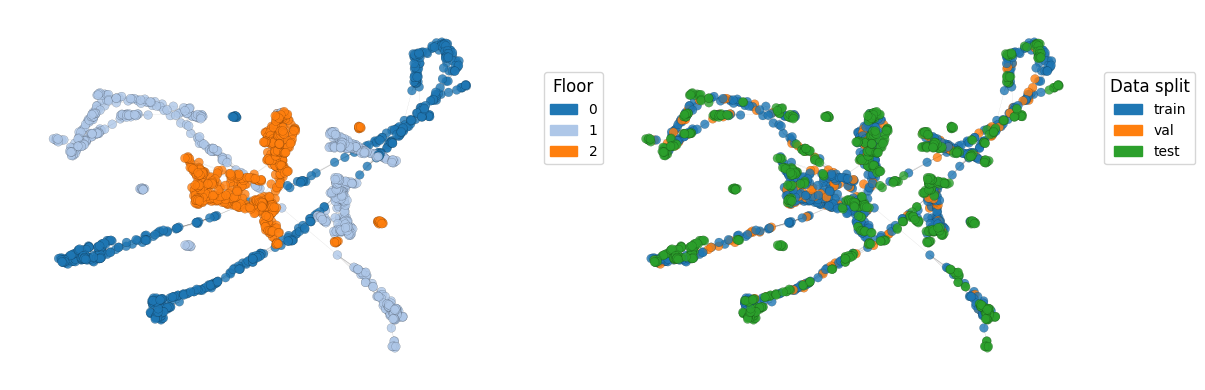

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 

clusters = ['class', 'split']
graph_data = graph_datas['SOD01'][3]['transductive'].cls

for ax, cluster in zip(axes, clusters):
    gvizs.draw_graph(graph_data, scheme="transductive", cluster=cluster, ax=ax) 
    
plt.tight_layout()
plt.show()

**Inductive scheme**

In [28]:
dataset="UJI1"

In [31]:
gvizs = indoorloc_vizs.GraphVisualizer()

In [36]:
graph_datas[dataset][4]['inductive'].reg

{'train': Data(num_nodes=17874, x=[17874, 89], num_features=89, edge_index=[2, 215696], k=9, y=[17874, 2], y_scaler=MinMaxScaler(), num_classes=0),
 'val': Data(num_nodes=1987, x=[1987, 89], num_features=89, edge_index=[2, 23664], k=9, y=[1987, 2], y_scaler=MinMaxScaler(), num_classes=0),
 'test': Data(num_nodes=1111, x=[1111, 89], num_features=89, edge_index=[2, 12854], k=9, y=[1111, 2], y_scaler=MinMaxScaler(), num_classes=0)}

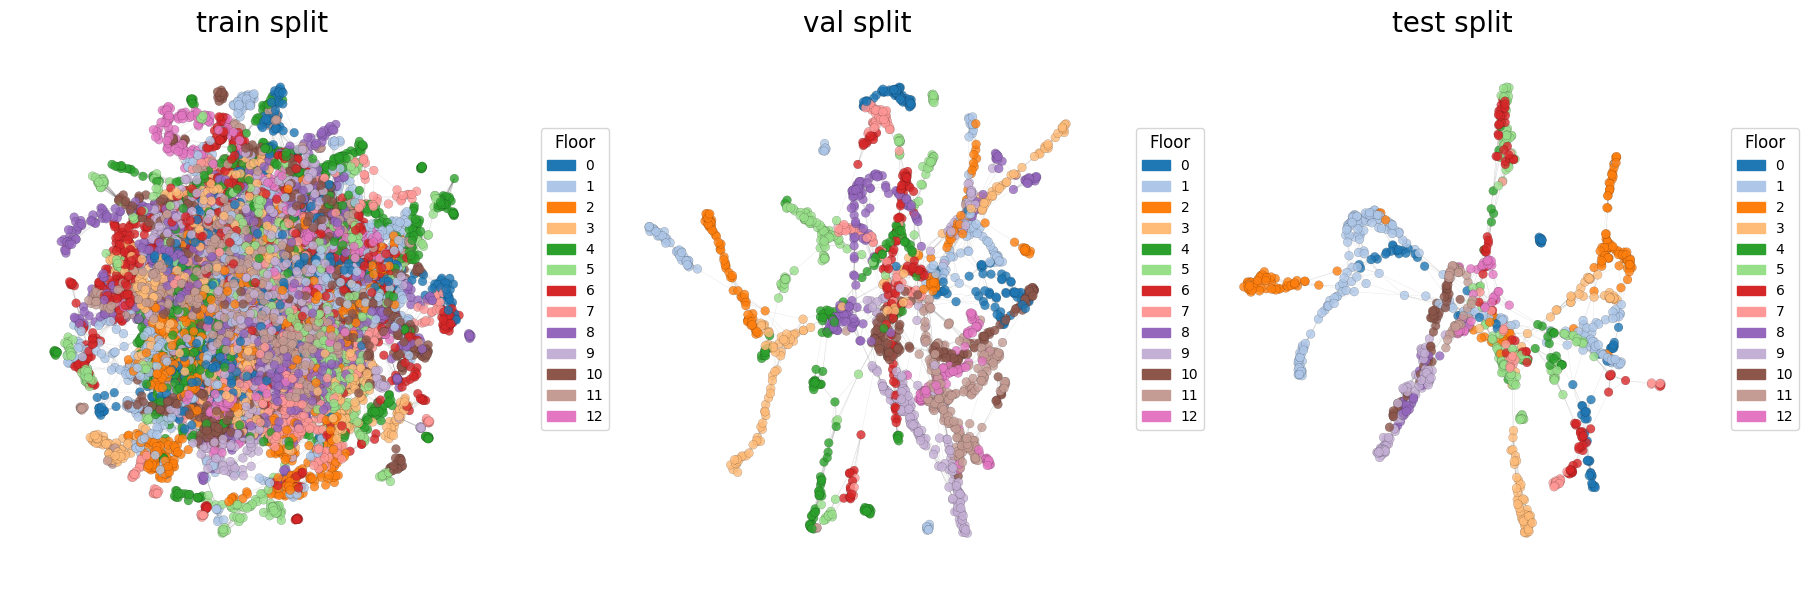

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 

splits = ['train', 'val', 'test']
graph_objs = [
    graph_datas[dataset][3]['inductive'].cls['train'],
    graph_datas[dataset][3]['inductive'].cls['val'],
    graph_datas[dataset][3]['inductive'].cls['test']
]

for ax, split, gdata in zip(axes, splits, graph_objs):
    gvizs.draw_graph(gdata, scheme="inductive", cluster="class", ax=ax) 
    ax.set_title(f"{split} split", fontsize=20)

plt.tight_layout()
plt.show()

# 3. Training & Inference

## Regression

### Training

Epoch 01 => Train Loss: 0.6091 | Validation Loss: 60.1104
Epoch 50 => Train Loss: 0.0353 | Validation Loss: 4.9587
Epoch 100 => Train Loss: 0.0281 | Validation Loss: 4.7164
Epoch 150 => Train Loss: 0.0267 | Validation Loss: 4.6671
Epoch 200 => Train Loss: 0.0232 | Validation Loss: 4.2582
Epoch 250 => Train Loss: 0.0208 | Validation Loss: 4.0000
Epoch 300 => Train Loss: 0.0177 | Validation Loss: 4.0255
Epoch 350 => Train Loss: 0.0163 | Validation Loss: 4.0431
Epoch 400 => Train Loss: 0.0147 | Validation Loss: 3.9093
Epoch 450 => Train Loss: 0.0128 | Validation Loss: 3.7583
Epoch 500 => Train Loss: 0.0117 | Validation Loss: 3.8980


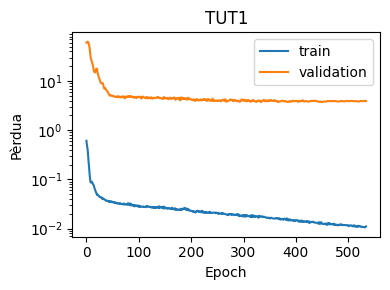

In [84]:
dataset = "TUT1"
scheme = "inductive"
#scheme = "transductive"
graph_data = graph_datas[dataset][0][scheme]
input_dim = graph_data.reg['train'].num_features if scheme == "inductive" \
            else graph_data.reg.num_features
model_params = {
    'input_dim': input_dim,
    'hidden_dim': [256, 256],
    'output_dim': 2, 
    'n_layers': 2,
    'dropout': [0.4],
    'learning_rate': 1e-2,
    'optim_factor': 0.9,
    'weight_decay': 1e-4,
    'mlp_layers': 4
}
model = SAGERegressor(**model_params).to("cuda")

trainer = GNNRegressionTrainer(dataset=dataset, scheme=scheme).train_validate(
    data=graph_data.reg, 
    model=model,
    verbose=2,
    max_epochs=800,
    patience=200,
    show_train_process=True
)

### Inference (Testing)

In [85]:
prediction = GNNRegressionTrainer(dataset=dataset, scheme=scheme)._test(
    data=graph_data.reg, 
    model=model
)
f"MPE={prediction['mpe']:.2f} | MAE={prediction['mae']:.2f} \
| MAE_X={prediction['mae_x']:.2f} | MAE_Y={prediction['mae_y']:.2f}"

'MPE=7.65 | MAE=4.67 | MAE_X=5.82 | MAE_Y=3.51'